# 🧠 Entrenamiento DayCategoryClassifier

Notebook para entrenar el modelo CoreML que clasifica días laborales en 7 categorías.

**Categorías:**
- 0: 🌴 Rest (Descanso)
- 1: 🧘 Calm (Tranquilo)
- 2: ⚡ Balanced (Balanceado)
- 3: 📅 Busy (Ocupado)
- 4: 🔥 Intense (Intenso)
- 5: 🎯 DeepFocus (Foco Profundo)
- 6: 🚨 BurnoutRisk (Riesgo Burnout)

## 1. Instalación de dependencias

In [1]:
# Instalar dependencias necesarias
!pip install pandas numpy scikit-learn coremltools matplotlib seaborn -q

print("✅ Dependencias instaladas")

✅ Dependencias instaladas


## 2. Cargar datos

In [2]:
import pandas as pd
import numpy as np

# Cargar datasets
train_df = pd.read_csv('TRAINING.csv')
val_df = pd.read_csv('VALIDATION.csv')
test_df = pd.read_csv('TESTING.csv')

print("📊 Dataset shapes:")
print(f"  Training: {train_df.shape}")
print(f"  Validation: {val_df.shape}")
print(f"  Testing: {test_df.shape}")

# Ver primeras filas
print("\n🔍 Primeras filas del dataset de entrenamiento:")
train_df.head()

📊 Dataset shapes:
  Training: (1750, 10)
  Validation: (375, 10)
  Testing: (375, 10)

🔍 Primeras filas del dataset de entrenamiento:


,dayOfWeek,isWeekend,isHoliday,totalMeetingCount,hasImportantDeadline,backToBackMeetings,freeTimeBlocks,meetingDensityScore,interruptionRiskScore,dayCategory
0,4,0,0,5,1,1,4,67,57,3
1,1,1,0,4,0,0,6,41,48,2
2,3,0,0,3,0,0,3,36,46,2
3,5,0,0,3,1,0,5,38,21,5
4,5,0,0,5,1,1,3,53,52,3


## 3. Análisis exploratorio

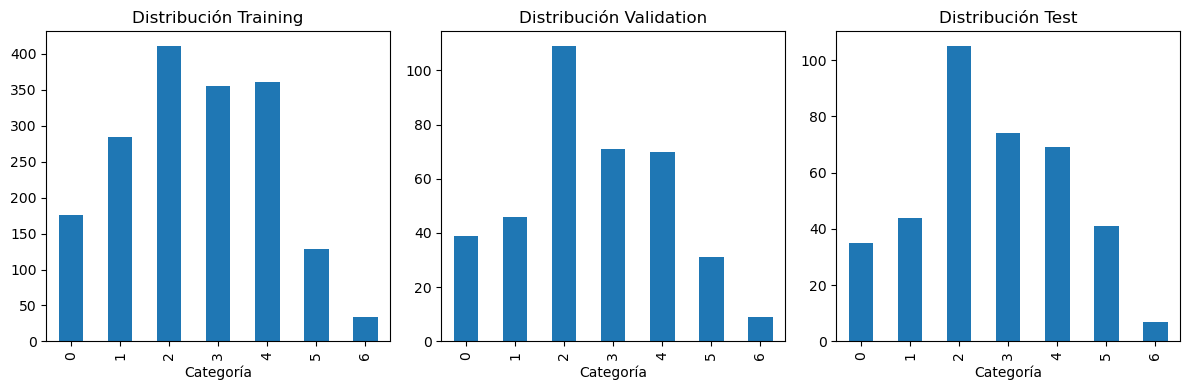


📈 Estadísticas de features:


,dayOfWeek,isWeekend,isHoliday,totalMeetingCount,hasImportantDeadline,backToBackMeetings,freeTimeBlocks,meetingDensityScore,interruptionRiskScore,dayCategory
count,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000
mean,3.726286,0.117143,0.026857,4.000571,0.417714,0.320000,4.415429,43.760000,46.068571,2.548571
std,1.607567,0.321682,0.161712,2.433683,0.493324,0.466609,2.368434,25.344704,26.854560,1.504210
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,3.000000,23.000000,25.000000,1.000000
50%,4.000000,0.000000,0.000000,4.000000,0.000000,0.000000,4.000000,44.000000,45.000000,3.000000
75%,5.000000,0.000000,0.000000,6.000000,1.000000,1.000000,6.000000,67.000000,71.000000,4.000000
max,7.000000,1.000000,1.000000,10.000000,1.000000,1.000000,9.000000,100.000000,100.000000,6.000000


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribución de clases
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
train_df['dayCategory'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución Training')
plt.xlabel('Categoría')

plt.subplot(1, 3, 2)
val_df['dayCategory'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución Validation')
plt.xlabel('Categoría')

plt.subplot(1, 3, 3)
test_df['dayCategory'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución Test')
plt.xlabel('Categoría')

plt.tight_layout()
plt.show()

# Estadísticas
print("\n📈 Estadísticas de features:")
train_df.describe()

## 4. Preparar datos para entrenamiento

In [4]:
# Features y target
feature_columns = [
    'dayOfWeek',
    'isWeekend',
    'isHoliday',
    'totalMeetingCount',
    'hasImportantDeadline',
    'backToBackMeetings',
    'freeTimeBlocks',
    'meetingDensityScore',
    'interruptionRiskScore'
]

target_column = 'dayCategory'

# Separar X e y
X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_val = val_df[feature_columns]
y_val = val_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

print(f"✅ Features: {len(feature_columns)}")
print(f"   {feature_columns}")
print(f"\n🎯 Target: {target_column}")
print(f"   Clases: {sorted(y_train.unique())}")

✅ Features: 9
   ['dayOfWeek', 'isWeekend', 'isHoliday', 'totalMeetingCount', 'hasImportantDeadline', 'backToBackMeetings', 'freeTimeBlocks', 'meetingDensityScore', 'interruptionRiskScore']

🎯 Target: dayCategory
   Clases: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


## 5. Entrenar modelo - Random Forest

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Crear y entrenar modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("🚀 Entrenando Random Forest...")
rf_model.fit(X_train, y_train)

# Predicciones
y_pred = rf_model.predict(X_test)

# Evaluar
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

🚀 Entrenando Random Forest...

✅ Accuracy: 0.9707 (97.07%)


## 6. Evaluación detallada

📊 Classification Report:
              precision    recall  f1-score   support

        Rest       1.00      1.00      1.00        35
        Calm       1.00      0.95      0.98        44
    Balanced       0.97      0.96      0.97       105
        Busy       0.99      0.99      0.99        74
     Intense       0.99      0.99      0.99        69
   DeepFocus       0.86      0.93      0.89        41
 BurnoutRisk       1.00      1.00      1.00         7

    accuracy                           0.97       375
   macro avg       0.97      0.97      0.97       375
weighted avg       0.97      0.97      0.97       375



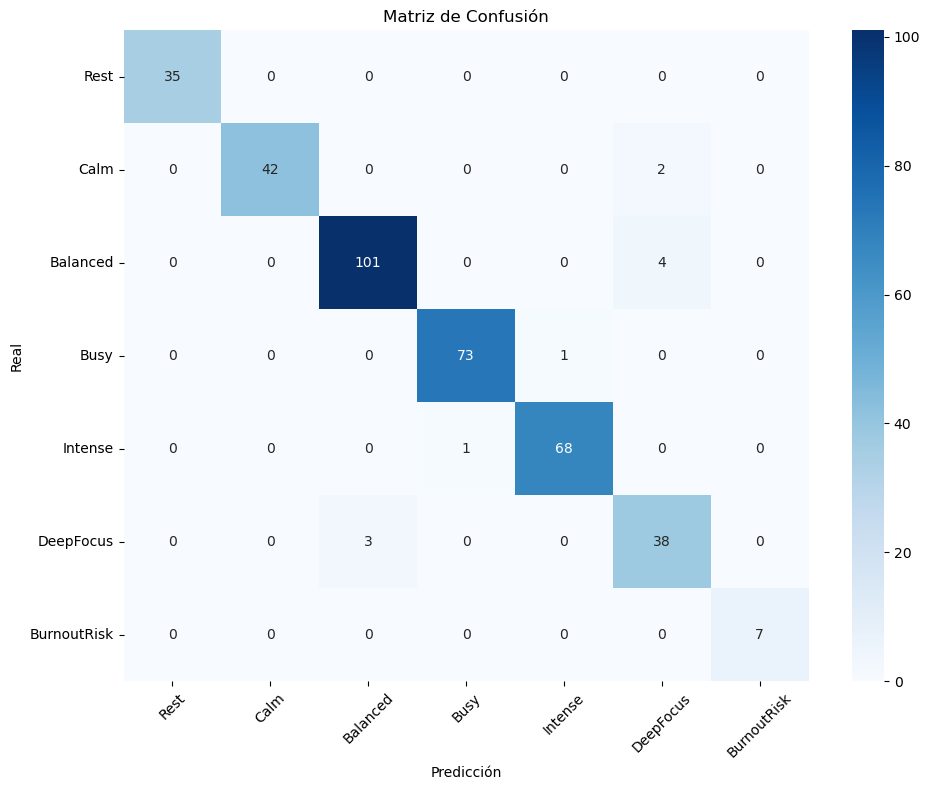

In [6]:
# Classification report
categories = ['Rest', 'Calm', 'Balanced', 'Busy', 'Intense', 'DeepFocus', 'BurnoutRisk']

print("📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=categories))

# Matriz de confusión
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories,
            yticklabels=categories)
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Importancia de features

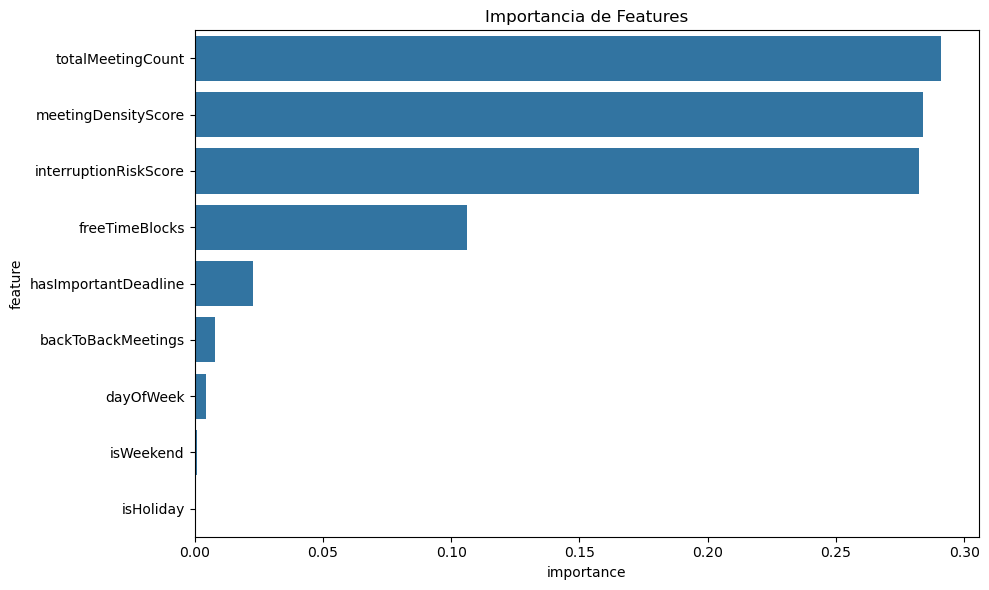


📊 Feature Importance:
                 feature  importance
3      totalMeetingCount    0.291027
7    meetingDensityScore    0.284030
8  interruptionRiskScore    0.282332
6         freeTimeBlocks    0.106068
4   hasImportantDeadline    0.022810
5     backToBackMeetings    0.008083
0              dayOfWeek    0.004380
1              isWeekend    0.000836
2              isHoliday    0.000432


In [7]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Importancia de Features')
plt.tight_layout()
plt.show()

print("\n📊 Feature Importance:")
print(importance_df)

## 8. Guardar modelo sklearn

In [8]:
import joblib

# Guardar modelo
model_filename = 'DayCategoryClassifier.pkl'
joblib.dump(rf_model, model_filename)

print(f"💾 Modelo guardado: {model_filename}")

# Verificar que se puede cargar
loaded_model = joblib.load(model_filename)
test_pred = loaded_model.predict(X_test[:5])
print(f"✅ Modelo cargado correctamente. Predicción de prueba: {test_pred}")

💾 Modelo guardado: DayCategoryClassifier.pkl
✅ Modelo cargado correctamente. Predicción de prueba: [4 2 3 0 1]


## 9. Convertir a CoreML (.mlmodel)

Este es el paso más importante para usar el modelo en la app Swift.

In [9]:
import coremltools as ct
import os
# Convertir modelo a CoreML
print("🔄 Convirtiendo a CoreML...")

# Definir tipos de entrada
input_features = [
    ('dayOfWeek', ct.models.datatypes.Int64()),
    ('isWeekend', ct.models.datatypes.Int64()),
    ('isHoliday', ct.models.datatypes.Int64()),
    ('totalMeetingCount', ct.models.datatypes.Int64()),
    ('hasImportantDeadline', ct.models.datatypes.Int64()),
    ('backToBackMeetings', ct.models.datatypes.Int64()),
    ('freeTimeBlocks', ct.models.datatypes.Int64()),
    ('meetingDensityScore', ct.models.datatypes.Int64()),
    ('interruptionRiskScore', ct.models.datatypes.Int64()),
]

# Crear especificación
coreml_model = ct.converters.sklearn.convert(
    rf_model,
    input_features=feature_columns,
    output_feature_names='dayCategory'
)

# Configurar metadata
coreml_model.author = 'Busylight Team'
coreml_model.license = 'MIT'
coreml_model.short_description = 'Clasifica días laborales en 7 categorías: Rest, Calm, Balanced, Busy, Intense, DeepFocus, BurnoutRisk'

# Guardar modelo
mlmodel_filename = 'DayCategoryClassifier.mlmodel'
coreml_model.save(mlmodel_filename)

print(f"✅ CoreML model guardado: {mlmodel_filename}")
print(f"📦 Tamaño: {os.path.getsize(mlmodel_filename) / 1024:.2f} KB")

🔄 Convirtiendo a CoreML...
✅ CoreML model guardado: DayCategoryClassifier.mlmodel
📦 Tamaño: 381.78 KB


## 10. Verificar modelo CoreML

In [10]:
# Verificar el modelo generado
import os

print("🔍 Verificando modelo CoreML:")
print(f"   Archivo: {mlmodel_filename}")
print(f"   Existe: {os.path.exists(mlmodel_filename)}")

# Cargar y verificar
loaded_mlmodel = ct.models.MLModel(mlmodel_filename)
print(f"\n📋 Descripción:")
print(loaded_mlmodel.description)

🔍 Verificando modelo CoreML:
   Archivo: DayCategoryClassifier.mlmodel
   Existe: True

📋 Descripción:


AttributeError: 'MLModel' object has no attribute 'description'

## 11. Probar predicción con el modelo CoreML

In [ ]:
# Probar predicción
sample_input = {
    'dayOfWeek': 2,      # Lunes
    'isWeekend': 0,      # No es fin de semana
    'isHoliday': 0,      # No es feriado
    'totalMeetingCount': 5,     # 5 reuniones
    'hasImportantDeadline': 1,  # Tiene deadline
    'backToBackMeetings': 1,    # Reuniones seguidas
    'freeTimeBlocks': 2,        # 2 bloques libres
    'meetingDensityScore': 60,  # 60% densidad
    'interruptionRiskScore': 70 # 70% riesgo
}

categories_map = {
    0: '🌴 Rest',
    1: '🧘 Calm',
    2: '⚡ Balanced',
    3: '📅 Busy',
    4: '🔥 Intense',
    5: '🎯 DeepFocus',
    6: '🚨 BurnoutRisk'
}

# Predicción con sklearn
sklearn_pred = rf_model.predict([list(sample_input.values())])[0]
print("🧪 Predicción con sklearn:")
print(f"   Input: {sample_input}")
print(f"   Predicción: {sklearn_pred} - {categories_map[sklearn_pred]}")

# Predicción con CoreML
coreml_pred = loaded_mlmodel.predict(sample_input)
predicted_class = int(coreml_pred['dayCategory'])
print(f"\n🍎 Predicción con CoreML:")
print(f"   Predicción: {predicted_class} - {categories_map[predicted_class]}")

## 12. Guardar métricas del modelo

In [ ]:
import json

# Calcular métricas por clase
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None)

metrics = {
    'model_name': 'DayCategoryClassifier',
    'algorithm': 'Random Forest',
    'accuracy': float(accuracy),
    'n_estimators': 100,
    'max_depth': 15,
    'training_samples': len(X_train),
    'validation_samples': len(X_val),
    'test_samples': len(X_test),
    'features': feature_columns,
    'categories': categories,
    'metrics_by_class': {
        cat: {
            'precision': float(precision[i]),
            'recall': float(recall[i]),
            'f1': float(f1[i]),
            'support': int(support[i])
        }
        for i, cat in enumerate(categories)
    },
    'feature_importance': {
        row['feature']: float(row['importance'])
        for _, row in importance_df.iterrows()
    }
}

# Guardar métricas
with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("💾 Métricas guardadas: model_metrics.json")
print(f"\n📊 Resumen:")
print(f"   Accuracy: {accuracy*100:.2f}%")
print(f"   Promedio Precision: {precision.mean()*100:.2f}%")
print(f"   Promedio Recall: {recall.mean()*100:.2f}%")
print(f"   Promedio F1: {f1.mean()*100:.2f}%")

## 📋 Resumen Final

Archivos generados:
- `DayCategoryClassifier.pkl` - Modelo sklearn
- `DayCategoryClassifier.mlmodel` - Modelo CoreML para iOS/macOS
- `model_metrics.json` - Métricas de evaluación

**Para usar en la app:**
1. Copia `DayCategoryClassifier.mlmodel` al proyecto Xcode
2. Selecciona el archivo en Xcode → Target Membership → Check tu app
3. Xcode generará automáticamente la clase `DayCategoryClassifier`
4. Usa: `DayCategoryClassifierWrapper.shared.predictToday(...)`